In [5]:
# Tests the GeoTikzBridge FastAPI endpoint

from pathlib import Path
import json
import requests
from PIL import Image, ImageDraw
from IPython.display import display, Markdown, Image as IPyImage


In [6]:
# Configuration

BASE_URL = "http://127.0.0.1:8007"
HEALTH_URL = f"{BASE_URL}/health"
PREDICT_URL = f"{BASE_URL}/geotikzbridge"

# Increase if inference is slow.
REQUEST_TIMEOUT_SECONDS = 600

print("Health URL:", HEALTH_URL)
print("Predict URL:", PREDICT_URL)

Health URL: http://127.0.0.1:8007/health
Predict URL: http://127.0.0.1:8007/geotikzbridge


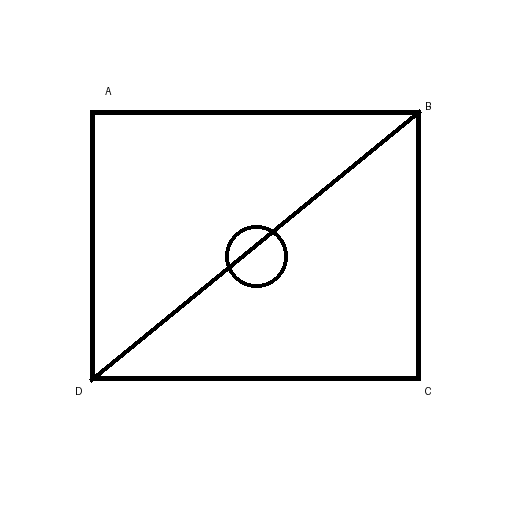

In [7]:
# Create simple test files

IMAGE_PATH = Path("geotikzbridge_test.png")
DESCRIPTION_PATH = Path("geotikzbridge_description.txt")

img = Image.new("RGB", (512, 512), "white")
draw = ImageDraw.Draw(img)
draw.rectangle((90, 110, 420, 380), outline="black", width=5)
draw.line((90, 380, 420, 110), fill="black", width=4)
draw.ellipse((225, 225, 287, 287), outline="black", width=4)
draw.text((105, 85), "A", fill="black")
draw.text((425, 100), "B", fill="black")
draw.text((425, 385), "C", fill="black")
draw.text((75, 385), "D", fill="black")
img.save(IMAGE_PATH)

DESCRIPTION_PATH.write_text(
    "A rectangle ABCD with diagonal DB and a circle at the center.",
    encoding="utf-8",
)

display(IPyImage(filename=str(IMAGE_PATH)))


In [8]:
# Call GeoTikzBridge API

def call_geotikzbridge(
    image_path: str | Path,
    description_path: str | Path,
    prompt: str = "Generate the TikZ code for this geometry image.",
    use_llm_description: bool = True,
    debug: bool = True,
) -> dict:
    image_path = Path(image_path)
    description_path = Path(description_path)

    with image_path.open("rb") as image_file, description_path.open("rb") as description_file:
        response = requests.post(
            PREDICT_URL,
            files={
                "image": (image_path.name, image_file, "image/png"),
                "llm_description": (
                    description_path.name,
                    description_file,
                    "text/plain",
                ),
            },
            data={
                "prompt": prompt,
                "use_llm_description": str(use_llm_description).lower(),
                "debug": str(debug).lower(),
            },
            timeout=REQUEST_TIMEOUT_SECONDS,
        )

    response.raise_for_status()
    return response.json()


result = call_geotikzbridge(IMAGE_PATH, DESCRIPTION_PATH)
print(json.dumps(result, indent=2)[:4000])


{
  "model": "geotikzbridge",
  "model_checkpoint": "/models/geotikzbridge-instruct-8b",
  "use_8bit": false,
  "tikz": "\\documentclass[tikz,border=3.14mm]{standalone}\n\\usepackage[UTF8]{ctex}\n\\usetikzlibrary{calc}\n\\begin{document}\n\\begin{tikzpicture}[font=\\sffamily]\n    \\draw[line width=1mm] (0,0) rectangle (8,6);\n    \\draw[line width=1mm] (4,3) circle (0.7);\n    \\draw[line width=1mm] (0,0) -- (8,6);\n    \n    % \u6dfb\u52a0\u8282\u70b9\u6807\u7b7e\n    \\node[anchor=north east,font=\\sffamily\\bfseries] at (0,0) {D};\n    \\node[anchor=north west,font=\\sffamily\\bfseries] at (8,0) {C};\n    \\node[anchor=south west,font=\\sffamily\\bfseries] at (8,6) {B};\n    \\node[anchor=south west,font=\\sffamily\\bfseries] at (0,6) {A};\n    \n    % \u6dfb\u52a0\u5bf9\u89d2\u7ebf\u6807\u7b7e\n    \\node[anchor=south,font=\\sffamily\\bfseries] at (4,6) {A};\n    \\node[anchor=north,font=\\sffamily\\bfseries] at (4,0) {C};\n    \\node[anchor=east,font=\\sffamily\\bfseries] at (0,3

In [9]:
# Display and save TikZ output

tikz_code = result.get("tikz", "")

print("Model:", result.get("model"))
print("Checkpoint:", result.get("model_checkpoint"))
print("TikZ characters:", len(tikz_code))

display(Markdown("```tex\n" + tikz_code[:8000] + "\n```"))

out_path = Path("geotikzbridge_output.tex")
out_path.write_text(tikz_code, encoding="utf-8")

print("Saved TikZ output to:", out_path.resolve())

Model: geotikzbridge
Checkpoint: /models/geotikzbridge-instruct-8b
TikZ characters: 914


```tex
\documentclass[tikz,border=3.14mm]{standalone}
\usepackage[UTF8]{ctex}
\usetikzlibrary{calc}
\begin{document}
\begin{tikzpicture}[font=\sffamily]
    \draw[line width=1mm] (0,0) rectangle (8,6);
    \draw[line width=1mm] (4,3) circle (0.7);
    \draw[line width=1mm] (0,0) -- (8,6);
    
    % 添加节点标签
    \node[anchor=north east,font=\sffamily\bfseries] at (0,0) {D};
    \node[anchor=north west,font=\sffamily\bfseries] at (8,0) {C};
    \node[anchor=south west,font=\sffamily\bfseries] at (8,6) {B};
    \node[anchor=south west,font=\sffamily\bfseries] at (0,6) {A};
    
    % 添加对角线标签
    \node[anchor=south,font=\sffamily\bfseries] at (4,6) {A};
    \node[anchor=north,font=\sffamily\bfseries] at (4,0) {C};
    \node[anchor=east,font=\sffamily\bfseries] at (0,3) {D};
    \node[anchor=west,font=\sffamily\bfseries] at (8,3) {B};
    
    % 添加圆心标记
    \fill (4,3) circle (2pt);
\end{tikzpicture}
\end{document}
```

Saved TikZ output to: /home/jonas/PycharmProjects/tikzcodegenerator/evaluation/models/image-to-tikz/geotikzbridge-8b/geotikzbridge_output.tex
